autor = Melany Calderón-Osorno

versión = 0.1

fecha = 2026-03-17

# **Capacitación en Secuenciación por NGS  y análisis bioinformático de *Salmonella* spp. para la vigilancia en salud pública**

## **Procesamiento de resultados Identificación y/o caracterización de cepas bacterianas (Salmonella)**

Este instructivo tiene como objetivo que cada participante procese los resultados generados durante la etapa del pipeline de identificación y caracterización de cepas de *Salmonella*.

Para ello, se procesarán los resultados obtenidos mediante la herramienta **ARIBA**, empleada para la identificación de genes de resistencia a antibióticos y la determinación del MLST (Multi-Locus Sequence Typing). Asimismo, se integrarán los resultados generados por la herramienta **SeqSero2**, utilizada para determinar el serotipo de las cepas analizadas.


### **Procesamiento de datos de ARIBA para la identificación de AMR**

Para procesar los resultados de **ARIBA** asociados a resistencia a antimicrobianos, se utilizarán las salidas generadas con las bases de datos **CARD** y **VirulenceFinder**.

Se requieren tanto los archivos consolidados con los resultados de todas las muestras como los reportes individuales por muestra, los cuales permiten obtener el porcentaje de identidad de cada gen identificado.

A continuación, ejecute los siguientes comandos en la terminal para generar y renombrar los reportes individuales, ubicándolos en la misma carpeta donde se encuentran los archivos consolidados.

Ejecute el siguiente comando para renombrar los reportes generados con la base de datos **CARD**:

```
cd /home/jovyan/work/4-Practica_Caracterizacion/

for f in 1-ariba_amr/*_card;
do
base=$(basename ${f%_card})
cp $f/report.tsv 1-ariba_amr/${base}_card.tsv;
done
```
Ejecute el siguiente comando para renombrar reportes generados con la base de datos **VirulenceFinder**:

```
for f in 1-ariba_amr/*_vfdb;
do
base=$(basename ${f%_vfdb})
cp $f/report.tsv 1-ariba_amr/${base}_vfdb.tsv;
done
```








In [ ]:
#Importar las bibliotecas necesarias
import os
import re
import glob
import pandas as pd
import numpy as np
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import math
import warnings

In [ ]:
#Acceder directorio
os.chdir('/home/jovyan/work/4-Practica_Caracterizacion/1-ariba_amr')

In [ ]:
#Mostrar los archivos
fps_card = glob.glob('*_card.tsv')
fps_vfdb = glob.glob('*_vfdb.tsv')
fps_card[:3]
fps_vfdb[:3]

['849474_vfdb.tsv', '847828_vfdb.tsv']

In [ ]:
print(f"Cantidad de archivos analizados para la BD de CARD: {len(fps_card)}")
print(f"Cantidad de archivos analizados para la BD de VFDB: {len(fps_vfdb)}")

Cantidad de archivos analizados para la BD de CARD: 2
Cantidad de archivos analizados para la BD de VFDB: 2


In [ ]:
# Crear un DataFrame vacío donde se almacenarán los resultados combinados
card = pd.DataFrame()

# Iterar sobre la lista de archivos
for fp in fps_card:

    # Obtener solo el nombre del archivo
    filename = os.path.basename(fp)

    # Extraer el nombre de la muestra eliminando el sufijo '_card.tsv'
    sample_name = filename.replace('_card.tsv', '')

    # Leer el archivo TSV correspondiente a la muestra
    card_sample = pd.read_csv(fp, sep='\t')

    # Añadir una nueva columna con el nombre de la muestra
    card_sample['Sample'] = sample_name

    # Concatenar el DataFrame actual al acumulado
    card = pd.concat([card, card_sample])

    # Seleccionar únicamente las columnas de interés
    card = card[['Sample', 'cluster', 'pc_ident']]

# Mostrar las primeras filas del DataFrame final
card.head()

,Sample,cluster,pc_ident
0,847828,AAC_6___I-_3,98.40
1,847828,AAC_6___I-_3,98.40
2,847828,AAC_6___I-_3,98.40
3,847828,CRP,94.59
4,847828,Escherichia_coli_23S,97.85


In [ ]:
# Crear un DataFrame vacío para almacenar los resultados de VFDB
vfdb = pd.DataFrame()

# Iterar sobre la lista de archivos de VFDB
for fp in fps_vfdb:

    # Obtener el nombre del archivo sin la ruta
    filename = os.path.basename(fp)

    # Extraer el nombre de la muestra eliminando el sufijo '_vfdb.tsv'
    sample_name = filename.replace('_vfdb.tsv', '')

    # Leer el archivo TSV correspondiente a la muestra
    vfdb_sample = pd.read_csv(fp, sep='\t')

    # Añadir una columna con el nombre de la muestra
    vfdb_sample['Sample'] = sample_name

    # Concatenar el DataFrame de la muestra al DataFrame principal
    vfdb = pd.concat([vfdb, vfdb_sample])

    # Mantener solo las columnas de interés
    vfdb = vfdb[['Sample', 'cluster', 'pc_ident']]

# Mostrar las primeras filas del DataFrame final
vfdb.head()

,Sample,cluster,pc_ident
0,849474,nlpI_-,94.58
1,849474,nlpI_-,94.58
2,849474,nlpI_-,94.58
3,849474,nlpI_-,94.58
4,849474,nlpI_-,94.58


In [ ]:
# Leer el archivo CSV que contiene el resumen de resultados de CARD
card_report = pd.read_csv('card_summary.csv')

# Procesar la columna 'name' para extraer el nombre de la muestra
card_report['name'] = card_report['name'].str.split('/').str[1].str.split('_').str[0]

# Mostrar las primeras filas del DataFrame resultante
card_report.head()

,name,AAC_6___I-_3.match,Escherichia_coli_23S.match,MdtK.match,golS.match,mdsA.match,mdsB.match,mdsC.match,rrsB+.match,sdiA.match
0,847828,yes,yes,yes,yes,yes,yes,yes,yes,yes
1,849474,yes,yes,yes,yes,yes,yes,yes,yes,yes


In [ ]:
# Leer el archivo CSV que contiene el resumen de resultados de VFDB
vfdb_report = pd.read_csv('vfdb_summary.csv')

# Procesar la columna 'name' para extraer el nombre de la muestra
vfdb_report['name'] = vfdb_report['name'].str.split('/').str[1].str.split('_').str[0]

# Mostrar las primeras filas del DataFrame resultante
vfdb_report.head()

,name,cluster_319.match,nlpI_-.match
0,847828,yes,yes
1,849474,no,yes


In [ ]:
# Convertir la columna 'Sample' del DataFrame card a tipo string
card['Sample'] = card['Sample'].astype(str)

# Convertir la columna 'name' del DataFrame card_report a string
card_report['name'] = card_report['name'].astype(str)

# Convertir la columna 'Sample' del DataFrame vfdb a string
vfdb['Sample'] = vfdb['Sample'].astype(str)

# Convertir la columna 'name' del DataFrame vfdb_report a string
vfdb_report['name'] = vfdb_report['name'].astype(str)

In [ ]:
# Convertir el DataFrame de formato ancho a formato largo
card_long = card_report.melt(
    id_vars='name', #identificador
    var_name='cluster', #columnas a filas en cluster
    value_name='match' #valores asociados a match
)

# Limpiar los nombres de la columna 'cluster': Eliminar el sufijo '.match'
card_long['cluster'] = card_long['cluster'].str.replace('.match', '', regex=False)

# Mostrar el DataFrame resultante en formato largo
card_long

,name,cluster,match
0,847828,AAC_6___I-_3,yes
1,849474,AAC_6___I-_3,yes
2,847828,Escherichia_coli_23S,yes
3,849474,Escherichia_coli_23S,yes
4,847828,MdtK,yes
5,849474,MdtK,yes
6,847828,golS,yes
7,849474,golS,yes
8,847828,mdsA,yes
9,849474,mdsA,yes


In [ ]:
# Convertir el DataFrame de formato ancho a formato largo
vfdb_long = vfdb_report.melt(
    id_vars='name',
    var_name='cluster',
    value_name='match'
)

# Limpiar los nombres de la columna 'cluster':
vfdb_long['cluster'] = vfdb_long['cluster'].str.replace('.match', '', regex=False)

# Mostrar el DataFrame resultante en formato largo
vfdb_long

,name,cluster,match
0,847828,cluster_319,yes
1,849474,cluster_319,no
2,847828,nlpI_-,yes
3,849474,nlpI_-,yes


In [ ]:
# Realizar un merge entre card_long y card
merged_card = card_long.merge(
    card,
    left_on=['name', 'cluster'],
    right_on=['Sample', 'cluster'],
    how='left'
)

# Eliminar columnas que ya no son necesarias
merged_card = merged_card.drop(columns=['Sample', 'match'])

# Eliminar filas duplicadas
merged_card = merged_card.drop_duplicates()

# Mostrar el DataFrame final
merged_card

,name,cluster,pc_ident
0,847828,AAC_6___I-_3,98.40
3,849474,AAC_6___I-_3,96.80
7,847828,Escherichia_coli_23S,97.85
65,849474,Escherichia_coli_23S,97.73
129,847828,MdtK,98.67
132,849474,MdtK,98.81
136,847828,golS,99.35
137,849474,golS,99.57
138,847828,mdsA,98.94
143,849474,mdsA,98.86


In [ ]:
# Realizar un merge entre vfdb_long y vfdb
merged_vfdb = vfdb_long.merge(
    vfdb,
    left_on=['name', 'cluster'],
    right_on=['Sample', 'cluster'],
    how='left')

# Eliminar columnas que ya no son necesarias
merged_vfdb = merged_vfdb.drop(columns=['Sample','match'])

# Eliminar filas duplicadas
merged_vfdb = merged_vfdb.drop_duplicates()

# Mostrar el DataFrame final
merged_vfdb

,name,cluster,pc_ident
0,847828,cluster_319,91.36
35,849474,cluster_319,NaN
36,847828,nlpI_-,94.70
79,849474,nlpI_-,94.58


In [ ]:
# Crear una tabla matriz
merged_card_pivot = merged_card.pivot_table(
    index='name',
    columns='cluster',
    values='pc_ident',
    aggfunc='max'
)

# Reemplazar los valores NaN por 0
merged_card_pivot = merged_card_pivot.fillna(0).astype(int)

# Mostrar la matriz final
merged_card_pivot

cluster,AAC_6___I-_3,Escherichia_coli_23S,MdtK,golS,mdsA,mdsB,mdsC,rrsB+,sdiA
name,,,,,,,,,
847828,98,97,98,99,98,99,98,99,98
849474,96,97,98,99,98,99,98,99,99


In [ ]:
# Crear una tabla matriz
merged_vfdb_pivot = merged_vfdb.pivot_table(index='name', columns='cluster', values='pc_ident', aggfunc='max')

# Reemplazar los valores NaN por 0
merged_vfdb_pivot = merged_vfdb_pivot.fillna(0).astype(int)

# Mostrar la matriz final
merged_vfdb_pivot

cluster,cluster_319,nlpI_-
name,,
847828,91,94
849474,0,94


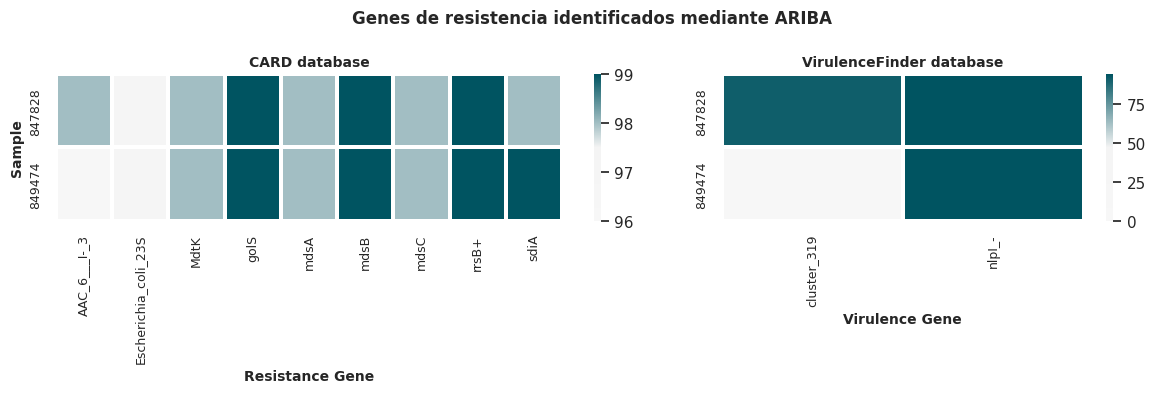

In [ ]:
# Colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_green", ["#F7F7F7", "#F4F4F4", "#005461"], N=500
)

sns.set(style="whitegrid")

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [7, 5]})

# Heatmap CARD
sns.heatmap(
    merged_card_pivot,
    cmap=cmap,
    linewidths=1.5,
    linecolor='white',
    ax=axes[0],
    cbar=True
)

axes[0].set_title("CARD database", fontsize=10, fontweight='bold')
axes[0].set_xlabel("Resistance Gene", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Sample", fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9, rotation=360)

# Heatmap VFDB
sns.heatmap(
    merged_vfdb_pivot,
    cmap=cmap,
    linewidths=1.5,
    linecolor='white',
    ax=axes[1],
    cbar=True
)

axes[1].set_title("VirulenceFinder database", fontsize=10, fontweight='bold')
axes[1].set_xlabel("Virulence Gene", fontsize=10, fontweight='bold')
axes[1].set_ylabel("")  # opcional quitar duplicado
axes[1].tick_params(axis='x', rotation=90, labelsize=9)
axes[1].tick_params(axis='y', labelsize=9, rotation=360)

# Título general
fig.suptitle("Genes de resistencia identificados mediante ARIBA", fontsize=12, fontweight='bold')

plt.tight_layout()

# Guardar
plt.savefig('ARIBA_AMR.pdf', dpi=600, bbox_inches="tight")

plt.show()

### **Procesamiento de datos de ARIBA para obtener el MLST**

Para procesar los resultados de **ARIBA** asociados al MLST, es necesario contar con los reportes individuales por muestra. Estos archivos permiten identificar los alelos por gen y determinar el tipo de secuencia (ST) correspondiente a cada muestra.

A continuación, ejecute el siguiente comando en la terminal para generar y renombrar los reportes individuales, guardándolos en la misma carpeta donde se encuentran los archivos consolidados.

Ejecute el siguiente comando:

```
cd /home/jovyan/work/4-Practica_Caracterizacion/

for f in 2-ariba_mlst/*_mlst;
do
base=$(basename ${f%_mlst})
cp $f/mlst_report.tsv 2-ariba_mlst/${base}_mlst.tsv;
done
```



In [ ]:
#Acceder directorio
os.chdir('/home/jovyan/work/4-Practica_Caracterizacion/2-ariba_mlst')

In [ ]:
#Mostrar los archivos
fps_mlst = glob.glob('*_mlst.tsv')
fps_mlst[:3]

['849474_mlst.tsv', '847828_mlst.tsv']

In [ ]:
print(f"Cantidad de archivos analizados para MLST: {len(fps_mlst)}")

Cantidad de archivos analizados para MLST: 2


In [ ]:
# Crear un DataFrame vacío para almacenar los resultados de MLST
mlst = pd.DataFrame()

# Iterar sobre la lista de archivos MLST
for fp in fps_mlst:

    # Obtener el nombre del archivo
    filename = os.path.basename(fp)

    # Extraer el nombre de la muestra eliminando el sufijo '_mlst.tsv'
    sample_name = filename.replace('_mlst.tsv', '')

    # Leer el archivo TSV correspondiente a la muestra
    mlst_sample = pd.read_csv(fp, sep='\t')

    # Añadir una columna con el nombre de la muestra
    mlst_sample['Sample'] = sample_name

    # Concatenar el DataFrame de la muestra al DataFrame principal
    mlst = pd.concat([mlst, mlst_sample])

# Establecer la columna 'Sample' como índice del DataFrame
mlst = mlst.set_index('Sample')

# Mostrar las primeras filas del DataFrame final
mlst.head()

,ST,aroC,dnaN,hemD,hisD,purE,sucA,thrA
Sample,,,,,,,,
849474,11,5,2,3,7,6,6,11
847828,94,42,46,48,48,40,35,4


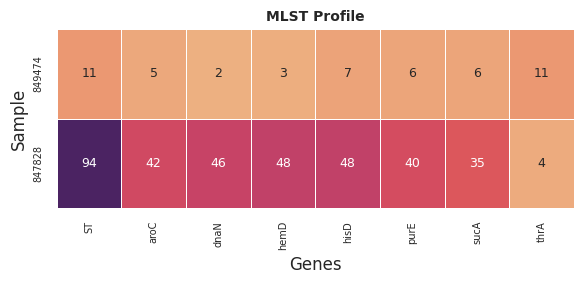

In [ ]:
# Importar librerías para visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Definir una paleta de colores para el heatmap
cmap = sns.color_palette("flare", as_cmap=True)


# Generar un heatmap a partir del DataFrame 'mlst'
plt.figure(figsize=(6, 3))
sns.heatmap(
    mlst,
    cmap=cmap,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    annot_kws={"size": 9}
)

# Añadir título al gráfico
plt.title("MLST Profile", fontsize=10, fontweight='bold')

plt.xlabel("Genes")
plt.ylabel("Sample")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)

plt.tight_layout()

# Guardar la figura en un archivo PDF
plt.savefig('ARIBA_MLST.pdf', dpi=600, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

### **Procesamiento de datos de SeqSero2 para obtener el serotipo**

Para procesar los resultados de **SeqSero2** asociados al serotipo, es necesario disponer de los reportes individuales por muestra. Estos archivos permiten identificar el serotipo predicho para cada muestra.

A continuación, ejecute el siguiente comando en la terminal para generar y renombrar los reportes individuales, guardándolos en la misma carpeta donde se encuentran los archivos consolidados.

Ejecute el siguiente comando:

```
cd /home/jovyan/work/4-Practica_Caracterizacion/

for f in 3-seqsero2/*;
do
base=$(basename ${f})
cp $f/SeqSero_result.tsv 3-seqsero2/${base}_seqsero.tsv;
done
```

In [ ]:
#Acceder directorio
os.chdir('/home/jovyan/work/4-Practica_Caracterizacion/3-seqsero2')

In [ ]:
#Mostrar los archivos
fps_seqsero = glob.glob('*_seqsero.tsv')
fps_seqsero[:3]

['849474_seqsero.tsv', '847828_seqsero.tsv']

In [ ]:
print(f"Cantidad de archivos analizados de SeqSero2: {len(fps_seqsero)}")

Cantidad de archivos analizados de SeqSero2: 2


In [ ]:
# Crear un DataFrame vacío para almacenar los resultados de SeqSero
seqsero = pd.DataFrame()

# Iterar sobre la lista de archivos SeqSero
for fp in fps_seqsero:

    # Obtener solo el nombre del archivo
    filename = os.path.basename(fp)

    # Extraer el nombre de la muestra eliminando el sufijo '_seqsero.tsv'
    sample_name = filename.replace('_seqsero.tsv', '')

    # Leer el archivo TSV correspondiente a la muestra
    seqsero_sample = pd.read_csv(fp, sep='\t')

    # Añadir una columna con el nombre de la muestra
    seqsero_sample['Sample'] = sample_name

    # Concatenar el DataFrame de la muestra al DataFrame principal
    seqsero = pd.concat([seqsero, seqsero_sample])

# Seleccionar únicamente las columnas de interés
seqsero = seqsero[['Sample',
                   'O antigen prediction',
                   'H1 antigen prediction(fliC)',
                   'H2 antigen prediction(fljB)',
                   'Predicted serotype']]

# Establecer la columna 'Sample' como índice del DataFrame
seqsero = seqsero.set_index('Sample')

# Mostrar las primeras filas del DataFrame final
seqsero.head()

,O antigen prediction,H1 antigen prediction(fliC),H2 antigen prediction(fljB),Predicted serotype
Sample,,,,
849474,9,"g,m",-,Enteritidis
847828,11,r,"e,n,x",Rubislaw


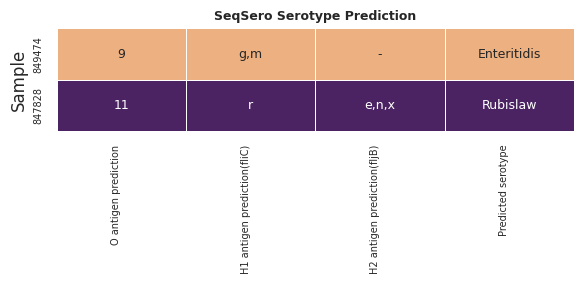

In [ ]:
# Crear una copia del DataFrame seqsero
seqsero_plot = seqsero.copy()

# Convertir las columnas categóricas a códigos numéricos
encoded = seqsero_plot.apply(lambda col: col.astype('category').cat.codes)

# Generar un heatmap de Seaborn
plt.figure(figsize=(6, 3))
sns.heatmap(
    encoded,
    cmap="flare",
    annot=seqsero_plot,
    fmt="",
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    annot_kws={"size": 9}
)

# Añadir título al gráfico
plt.title("SeqSero Serotype Prediction", fontsize=9, fontweight='bold')

plt.xlabel("")
plt.ylabel("Sample")
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

# Guardar la figura en PDF
plt.savefig('SeqSero.pdf', dpi=600, bbox_inches="tight")

# Mostrar el gráfico en pantalla
plt.show()

## **Descarga de archivos desde el entorno de ejecución**

En el panel izquierdo, ubique y descargue los siguientes archivos:
- **ARIBA_AMR.pdf**
- **ARIBA_MLST.pdf**
- **SeqSero.pdf**